## Ground Truth Priors

In [14]:
# Filepaths
# name: filepath
# TODO: Adapt with real filepaths
BASE = "outputs/new_experiments_try_4_presentation"
# MODELS = {
#     "Baseline": f"{BASE}/lego_baseline_no_prior",
#     "Baseline + direct": f"{BASE}/lego_photometric_warmup_direct",
#     "Baseline + zncc": f"{BASE}/lego_photometric_warmup_zncc",
#     "Albedo + zncc": f"{BASE}/lego_albedo_warmup_zncc"
# }
MODELS = {
    "Baseline": f"{BASE}/lego_baseline_no_prior",
    "With GT": f"{BASE}/lego_albedo_warmup_zncc",
    "With Diffusion Priors": f"{BASE}/lego_diffusion_zncc"
}

In [15]:
METRICS = MODELS.copy()
for x in METRICS:
    METRICS[x] += "/metrics_log.json"

In [16]:
METRICS

{'Baseline': 'outputs/new_experiments_try_4_presentation/lego_baseline_no_prior/metrics_log.json',
 'With GT': 'outputs/new_experiments_try_4_presentation/lego_albedo_warmup_zncc/metrics_log.json',
 'With Diffusion Priors': 'outputs/new_experiments_try_4_presentation/lego_diffusion_zncc/metrics_log.json'}

In [17]:
import json

METRICS_JSON = {}

for metric_key in METRICS:
    with open(f"{METRICS[metric_key]}") as metrics_json_file:
        METRICS_JSON[metric_key] = json.load(metrics_json_file)


In [18]:
metrics_60k_iteration = {}
for metric_key in METRICS_JSON:
    metrics_60k_iteration[metric_key] = METRICS_JSON[metric_key][-1]


In [19]:
METRICS_TO_SHOW_KEYS = {"test_psnr", "test_albedo_psnr_aligned", "test_normal_ang_err"}
filtered_metrics_60k_iteration = {}
for model in metrics_60k_iteration:
    model_metrics = metrics_60k_iteration[model]
    filtered_metrics_60k_iteration[model] = {key: model_metrics[key] for key in model_metrics.keys() & METRICS_TO_SHOW_KEYS}
# filtered_metrics_60k_iteration


In [20]:
filtered_metrics_60k_iteration

{'Baseline': {'test_albedo_psnr_aligned': 22.965615005493163,
  'test_normal_ang_err': 33.67657166481018,
  'test_psnr': 33.05949807167053},
 'With GT': {'test_albedo_psnr_aligned': 31.26259289741516,
  'test_normal_ang_err': 14.207390747070313,
  'test_psnr': 30.337521696090697},
 'With Diffusion Priors': {'test_albedo_psnr_aligned': 25.53318373680115,
  'test_normal_ang_err': 21.768738803863524,
  'test_psnr': 26.439242362976074}}

In [21]:
import matplotlib.pyplot as plt
import numpy as np

In [22]:
RELIGHTING_METRICS = MODELS.copy()
for x in METRICS:
    RELIGHTING_METRICS[x] += "/all_relighting/relighting_metrics.json"

In [23]:
RELIGHTING_METRICS

{'Baseline': 'outputs/new_experiments_try_4_presentation/lego_baseline_no_prior/all_relighting/relighting_metrics.json',
 'With GT': 'outputs/new_experiments_try_4_presentation/lego_albedo_warmup_zncc/all_relighting/relighting_metrics.json',
 'With Diffusion Priors': 'outputs/new_experiments_try_4_presentation/lego_diffusion_zncc/all_relighting/relighting_metrics.json'}

In [24]:
import json

RELIGHTING_JSON = {}

for metric_key in RELIGHTING_METRICS:
    with open(f"{RELIGHTING_METRICS[metric_key]}") as metrics_json_file:
        RELIGHTING_JSON[metric_key] = json.load(metrics_json_file)

In [25]:
import numpy as np

SELECTED_SCENES = {"city", "courtyard", "snow"}
KEY = "scale_invariant_psnr"
def calculate_mean_psnr(data, scenes_to_include=SELECTED_SCENES):
    mean_psnr = {}
    for model_name, scenes in data.items():
        psnr_values = [
            metrics[KEY]
            for scene_name, metrics in scenes.items()
            if scene_name in scenes_to_include
            and metrics[KEY] is not None
        ]
        mean_psnr[model_name] = np.mean(psnr_values) if psnr_values else None
    return mean_psnr

mean_psnr_by_model = calculate_mean_psnr(RELIGHTING_JSON)
print(mean_psnr_by_model)

{'Baseline': 22.5929265499115, 'With GT': 23.918064649899804, 'With Diffusion Priors': 23.106232208013534}


## This is the Script for creating the diagram

/tmp/ipykernel_3976302/1936697272.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


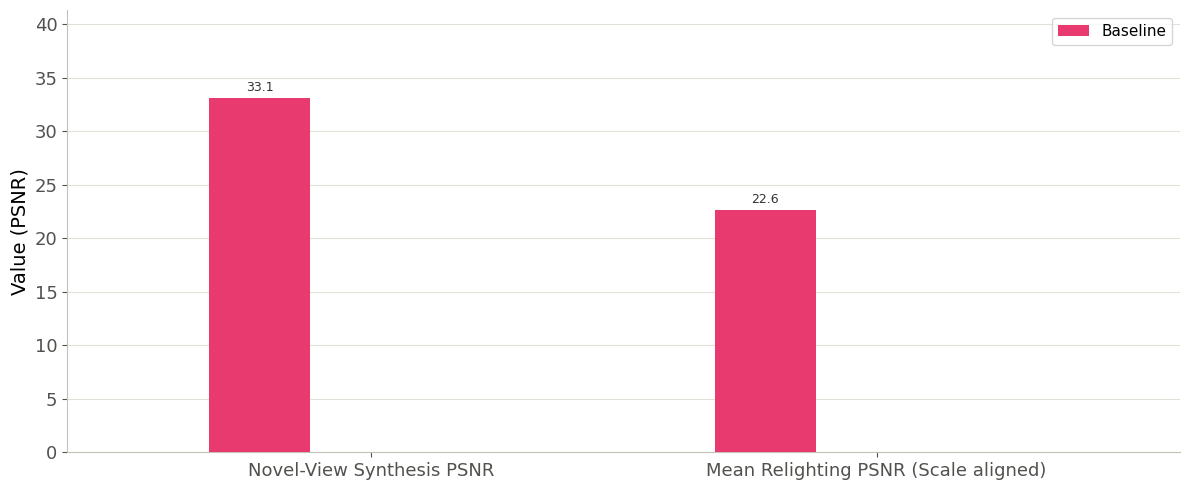

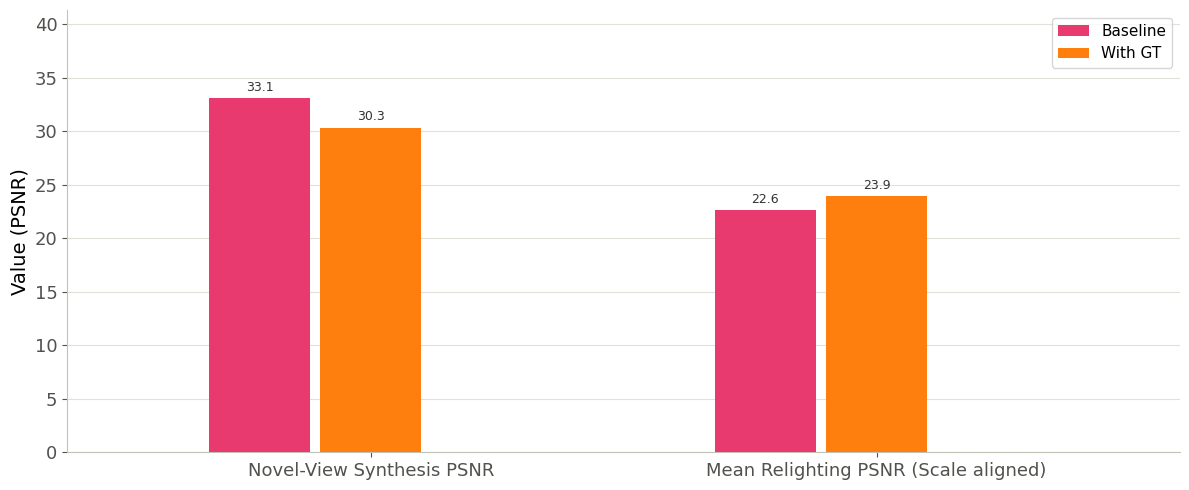

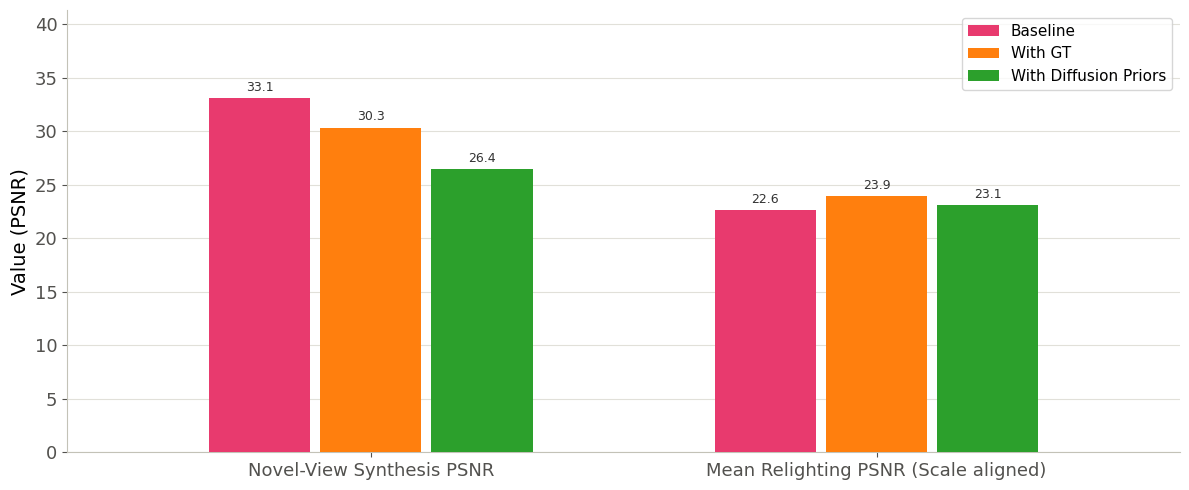

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

models = list(filtered_metrics_60k_iteration.keys())

color_map = {
    'Baseline': '#E83A6E',
    'Baseline + direct': '#4472C4',
    'Baseline + zncc': '#70AD47',
    'Albedo + zncc': '#9B59B6',
}
cmap = cm.get_cmap('tab10')
colors = [color_map.get(model, cmap(i % 10)) for i, model in enumerate(models)]

metric_labels = ['Novel-View Synthesis PSNR', 'Mean Relighting PSNR (Scale aligned)']

def get_vals(model):
    return [
        filtered_metrics_60k_iteration[model]['test_psnr'],
        mean_psnr_by_model[model],
        # filtered_metrics_60k_iteration[model]['test_albedo_psnr_aligned'],
    ]

n_metrics = 2
n_models = len(models)
bar_width = 0.2        # visual width of each bar
bar_step = 0.22         # spacing between bar centers within a group
x = np.arange(n_metrics)

y_max = max(
    v for model in models for v in get_vals(model) if v is not None
) * 1.25

for n_visible in range(1, n_models + 1):
    fig, ax = plt.subplots(figsize=(12, 5))

    for i, model in enumerate(models):
        offset = (i - (n_models - 1) / 2) * bar_step
        if i < n_visible:
            vals = get_vals(model)
            bars = ax.bar(x + offset, vals, bar_width, color=colors[i], label=model, zorder=3)

            for bar, val in zip(bars, vals):
                if val is not None:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        val + y_max * 0.01,
                        f'{val:.1f}',
                        ha='center', va='bottom',
                        fontsize=9, color='#333333'
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=14)
    ax.set_ylabel('Value (PSNR)', fontsize=14)
    ax.set_ylim(0, y_max)
    ax.set_xlim(-0.6, n_metrics - 0.4)
    ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#c3c2b7')
    ax.spines['bottom'].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e', labelsize=13)
    ax.legend(fontsize=11, frameon=True, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'outputs/comparison_{n_visible}models.pdf', dpi=150, bbox_inches='tight')
    plt.savefig(f"outputs/comparison_{n_visible}models.png")
    plt.show()

## Relighting Metrics

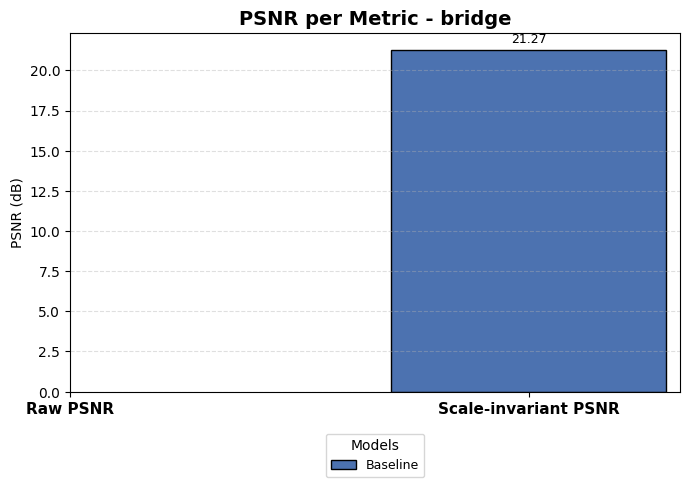

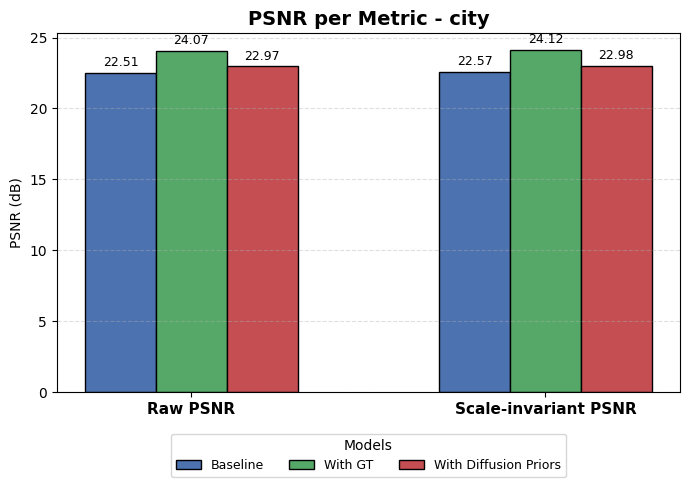

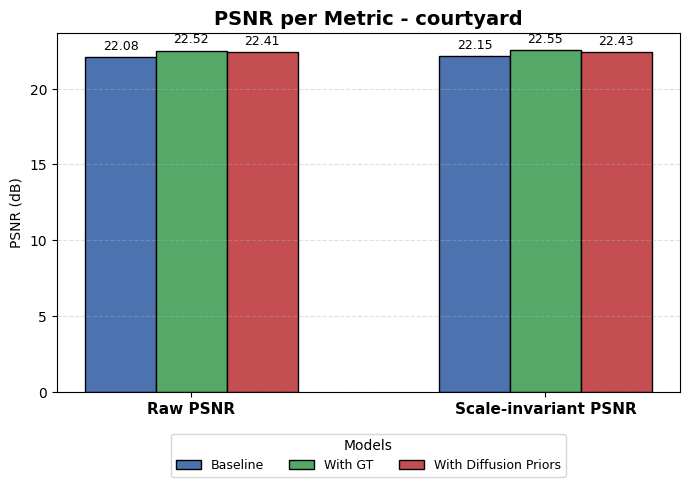

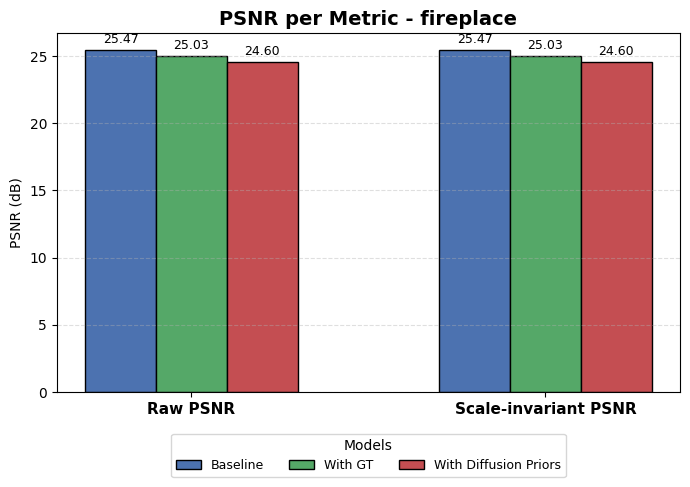

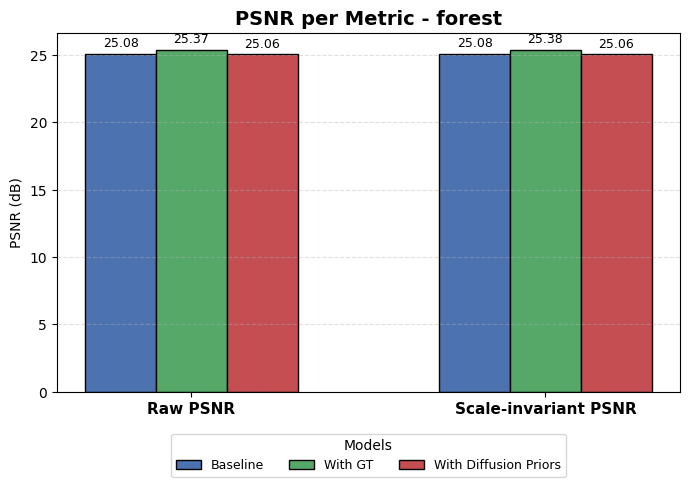

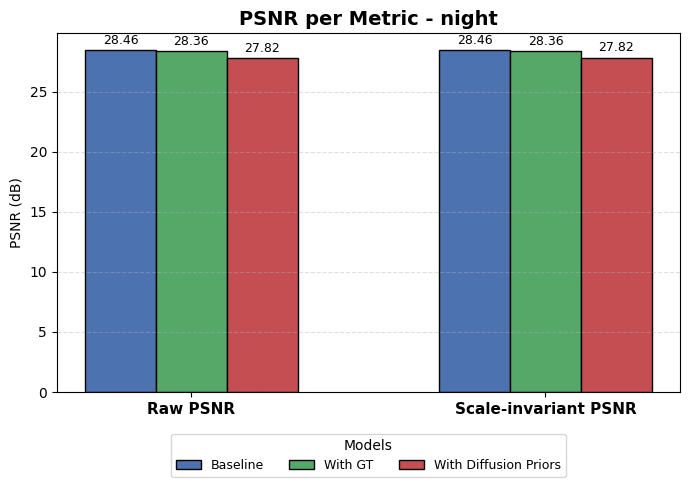

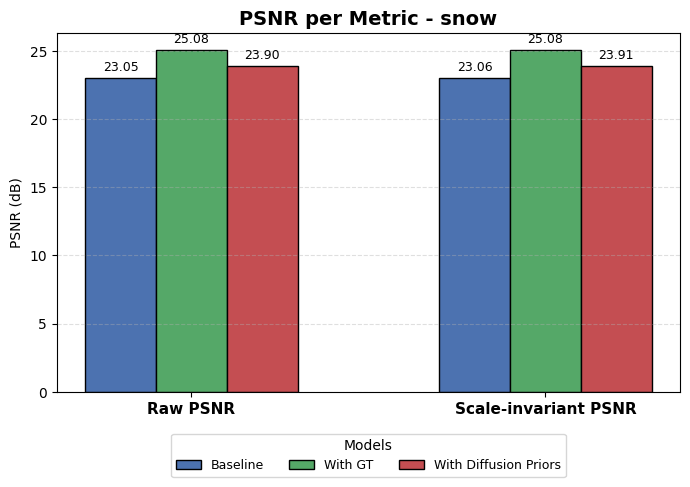

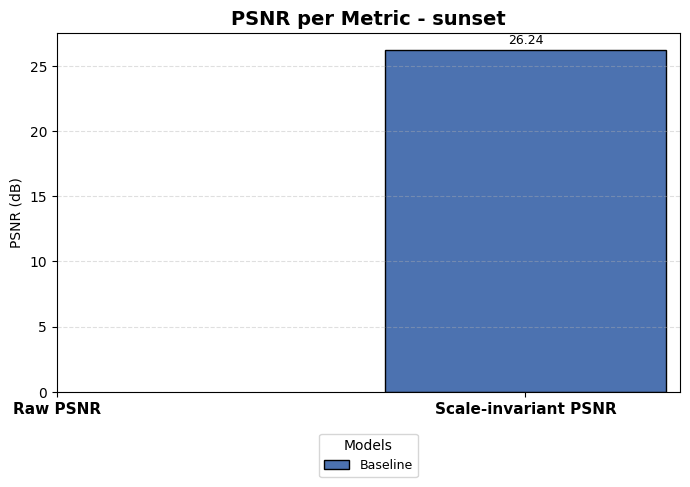

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming RELIGHTING_JSON is already defined
data = RELIGHTING_JSON
scenes = []
for method, method_data in data.items():
    for scene in method_data:
        if scene not in scenes:
            scenes.append(scene)
 
methods = list(data.keys())
colors = {'Baseline': '#4C72B0', 'With GT': '#55A868', 'With Diffusion Priors': '#C44E52'}

for scene in scenes:
    # Gather methods that have data for this scene
    present_methods = [m for m in methods if scene in data[m] and data[m][scene].get('scale_invariant_psnr') is not None]
 
    if not present_methods:
        continue
 
    fig, ax = plt.subplots(figsize=(7, 5))
 
    # We are grouping by metric now (X-axis ticks)
    metrics = ['Raw PSNR', 'Scale-invariant PSNR']
    x = np.arange(len(metrics))
    
    n_methods = len(present_methods)
    total_width = 0.6  # Total width for all bars within a single metric group
    width = total_width / n_methods
 
    for i, m in enumerate(present_methods):
        entry = data[m][scene]
        raw_val = entry.get('raw_psnr')
        si_val = entry.get('scale_invariant_psnr')
 
        # Using np.nan for missing raw values so matplotlib skips plotting them
        y_vals = [
            raw_val if raw_val is not None else np.nan,
            si_val if si_val is not None else np.nan
        ]
 
        # Calculate X position offset for this specific method's bar
        offset = (i - n_methods / 2 + 0.5) * width
        x_pos = x + offset
 
        # Fetch color from your dict, fallback to standard colormap if not found
        c = colors.get(m, plt.cm.tab10(i % 10))
 
        bars = ax.bar(x_pos, y_vals, width, label=m, color=c, edgecolor='black')
 
        # Add value text on top of the bars
        for bx, by in zip(x_pos, y_vals):
            if not np.isnan(by):
                ax.text(bx, by + 0.3, f'{by:.2f}', ha='center', va='bottom', fontsize=9)
 
    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
    ax.set_title(f'PSNR per Metric - {scene}', fontsize=14, fontweight='bold')
    ax.set_ylabel('PSNR (dB)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Legend formatting - placed below the chart to keep the metrics clear
    ax.legend(title='Models', fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(present_methods))
 
    fig.tight_layout()
    
    # Clean the scene name to ensure it's a valid filesystem path
    safe_scene_name = "".join([c if c.isalnum() else "_" for c in scene])
    
    # fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show() # Crucial: close the figure to free up memory on each loop iteration

In [35]:
data_to_analyze = RELIGHTING_JSON

In [ ]:
data_to_analyze

In [39]:
import pandas as pd
# Create a list to hold flattened records
records = []

for model_name, datasets in data_to_analyze.items():
    for dataset_name, metrics in datasets.items():
        # Initialize a dictionary for the row with our primary keys
        row = {'Model': model_name, 'Environment': dataset_name}
        # Merge the metrics into this row
        row.update(metrics)
        records.append(row)

# Create the DataFrame
df_flat = pd.DataFrame(records)

# Display the first few rows
print(df_flat.head())

      Model            Environment  scale_factor  scale_invariant_psnr  \
0  Baseline                 bridge      2.420197             21.268206   
1  Baseline                   city      1.016545             22.568840   
2  Baseline              courtyard      1.018450             22.148302   
3  Baseline              fireplace      1.006500             25.473655   
4  Baseline  flower_road_no_sun_2k           NaN                   NaN   

   scale_invariant_ssim  scale_invariant_mse   raw_psnr  raw_ssim   raw_mse  
0              0.828751             0.007844        NaN       NaN       NaN  
1              0.889567             0.005693  22.505011  0.889481  0.005795  
2              0.868071             0.006211  22.083935  0.867429  0.006305  
3              0.826792             0.002940  25.472586  0.826958  0.002941  
4                   NaN                  NaN        NaN       NaN       NaN  


In [40]:
df_flat

,Model,Environment,scale_factor,scale_invariant_psnr,scale_invariant_ssim,scale_invariant_mse,raw_psnr,raw_ssim,raw_mse
0,Baseline,bridge,2.420197,21.268206,0.828751,0.007844,NaN,NaN,NaN
1,Baseline,city,1.016545,22.568840,0.889567,0.005693,22.505011,0.889481,0.005795
2,Baseline,courtyard,1.018450,22.148302,0.868071,0.006211,22.083935,0.867429,0.006305
3,Baseline,fireplace,1.006500,25.473655,0.826792,0.002940,25.472586,0.826958,0.002941
4,Baseline,flower_road_no_sun_2k,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Baseline,forest,1.004969,25.081492,0.898957,0.003263,25.078214,0.899007,0.003266
6,Baseline,interior,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Baseline,lightroom_14b,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Baseline,museum,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Baseline,night,1.008497,28.464199,0.884790,0.001515,28.461586,0.885021,0.001516


In [41]:
datasets_to_keep = ["city", "courtyard", "fireplace", "forest", "snow", "night"]
df_filtered = df_flat[df_flat["Environment"].isin(datasets_to_keep)]

In [42]:
df_filtered

,Model,Environment,scale_factor,scale_invariant_psnr,scale_invariant_ssim,scale_invariant_mse,raw_psnr,raw_ssim,raw_mse
1,Baseline,city,1.016545,22.568840,0.889567,0.005693,22.505011,0.889481,0.005795
2,Baseline,courtyard,1.018450,22.148302,0.868071,0.006211,22.083935,0.867429,0.006305
3,Baseline,fireplace,1.006500,25.473655,0.826792,0.002940,25.472586,0.826958,0.002941
5,Baseline,forest,1.004969,25.081492,0.898957,0.003263,25.078214,0.899007,0.003266
9,Baseline,night,1.008497,28.464199,0.884790,0.001515,28.461586,0.885021,0.001516
11,Baseline,snow,1.005449,23.061638,0.887529,0.005012,23.054889,0.887442,0.005020
20,With GT,city,1.011935,24.120503,0.905119,0.004039,24.071440,0.904940,0.004094
21,With GT,courtyard,1.013128,22.551640,0.866356,0.005742,22.518570,0.865901,0.005792
22,With GT,fireplace,1.006837,25.034405,0.812591,0.003320,25.033351,0.812699,0.003320
23,With GT,night,1.007647,28.363741,0.876449,0.001506,28.361726,0.876544,0.001507


In [43]:
cols_to_remove = ["scale_factor", "scale_invariant_ssim", "scale_invariant_mse", "raw_ssim", "raw_mse"]
df_filtered2 = df_filtered.drop(columns=cols_to_remove)

In [44]:
df_filtered2

,Model,Environment,scale_invariant_psnr,raw_psnr
1,Baseline,city,22.568840,22.505011
2,Baseline,courtyard,22.148302,22.083935
3,Baseline,fireplace,25.473655,25.472586
5,Baseline,forest,25.081492,25.078214
9,Baseline,night,28.464199,28.461586
11,Baseline,snow,23.061638,23.054889
20,With GT,city,24.120503,24.071440
21,With GT,courtyard,22.551640,22.518570
22,With GT,fireplace,25.034405,25.033351
23,With GT,night,28.363741,28.361726


In [63]:
df_comparison_scale_invariant = df_flat.pivot(
    index='Environment', 
    columns='Model', 
    values='scale_invariant_psnr'
).dropna()

df_comparison_raw = df_flat.pivot(
    index='Environment', 
    columns='Model', 
    values='raw_psnr'
).dropna()

In [71]:
df_comparison_raw

Model,Baseline,With Diffusion Priors,With GT
Environment,,,
city,22.505011,22.965996,24.071440
courtyard,22.083935,22.408608,22.518570
fireplace,25.472586,24.596772,25.033351
forest,25.078214,25.058599,25.372224
night,28.461586,27.822486,28.361726
snow,23.054889,23.904598,25.079704


In [72]:
df_comparison_raw.style.highlight_max(axis=1, color='darkgoldenrod')

Model,Baseline,With Diffusion Priors,With GT
Environment,,,
city,22.505011,22.965996,24.071440
courtyard,22.083935,22.408608,22.518570
fireplace,25.472586,24.596772,25.033351
forest,25.078214,25.058599,25.372224
night,28.461586,27.822486,28.361726
snow,23.054889,23.904598,25.079704


In [73]:
# 1. Calculate the delta for Diffusion Priors vs Baseline
df_comparison_raw['Delta: Diffusion Priors'] = (
    df_comparison_raw['With Diffusion Priors'] - df_comparison_raw['Baseline']
)

# 2. Calculate the delta for GT vs Baseline
df_comparison_raw['Delta: GT'] = (
    df_comparison_raw['With GT'] - df_comparison_raw['Baseline']
)

In [74]:
# 3. Define the red/green formatting function
def color_deltas(value):
    if pd.isna(value):
        return ''
    # Green if positive (better), red if negative (worse)
    color = 'green' if value > 0 else 'red'
    return f'color: {color}; font-weight: bold;'

# 4. Apply the style ONLY to the delta columns
delta_columns = ['Delta: Diffusion Priors', 'Delta: GT']

# Note: Use .map() for pandas 2.1+, or .applymap() for older pandas versions
styled_df = (
    df_comparison_raw.style
    .map(color_deltas, subset=delta_columns)
    # Format all numbers to 2 decimal places for a clean look
    .format(precision=2) 
)

# Display the styled table
styled_df

Model,Baseline,With Diffusion Priors,With GT,Delta: Diffusion Priors,Delta: GT
Environment,,,,,
city,22.51,22.97,24.07,0.46,1.57
courtyard,22.08,22.41,22.52,0.32,0.43
fireplace,25.47,24.60,25.03,-0.88,-0.44
forest,25.08,25.06,25.37,-0.02,0.29
night,28.46,27.82,28.36,-0.64,-0.10
snow,23.05,23.90,25.08,0.85,2.02


In [75]:
styled_df.highlight_max(axis=1, color='darkgoldenrod')

Model,Baseline,With Diffusion Priors,With GT,Delta: Diffusion Priors,Delta: GT
Environment,,,,,
city,22.51,22.97,24.07,0.46,1.57
courtyard,22.08,22.41,22.52,0.32,0.43
fireplace,25.47,24.60,25.03,-0.88,-0.44
forest,25.08,25.06,25.37,-0.02,0.29
night,28.46,27.82,28.36,-0.64,-0.10
snow,23.05,23.90,25.08,0.85,2.02


## Material Evaluation

In [103]:
MATERIAL_METRIC = MODELS.copy()
for x in MATERIAL_METRIC:
    MATERIAL_METRIC[x] += "/material_evaluation_metrics.json"

In [104]:
import json

MATERIAL_METRICS_JSON = {}

for metric_key in METRICS:
    with open(f"{MATERIAL_METRIC[metric_key]}") as metrics_json_file:
        MATERIAL_METRICS_JSON[metric_key] = json.load(metrics_json_file)

In [105]:
MATERIAL_METRICS_JSON

{'Baseline': {'iteration': 60000,
  'num_test_views': 200,
  'albedo': {'global_channel_scale': {'R': 1.237844705581665,
    'G': 1.1019989252090454,
    'B': 0.6964060664176941},
   'mean_raw_psnr': 21.96434362411499,
   'mean_raw_ssim': 0.854208722114563,
   'mean_aligned_psnr': 23.298292999267577,
   'per_view': [{'view': 'rgba_000',
     'raw_psnr': 20.967811584472656,
     'raw_ssim': 0.8443794846534729,
     'aligned_psnr': 23.23810386657715},
    {'view': 'rgba_001',
     'raw_psnr': 20.939891815185547,
     'raw_ssim': 0.8466363549232483,
     'aligned_psnr': 23.231870651245117},
    {'view': 'rgba_002',
     'raw_psnr': 20.86670684814453,
     'raw_ssim': 0.8457523584365845,
     'aligned_psnr': 23.171682357788086},
    {'view': 'rgba_003',
     'raw_psnr': 20.781612396240234,
     'raw_ssim': 0.8462293148040771,
     'aligned_psnr': 23.096603393554688},
    {'view': 'rgba_004',
     'raw_psnr': 20.719608306884766,
     'raw_ssim': 0.8464406728744507,
     'aligned_psnr': 23.0

In [106]:
data = {}
for model in MATERIAL_METRICS_JSON:
    values = MATERIAL_METRICS_JSON[model]
    data[model] = {
        "Mean Albedo PSNR (aligned)": values["albedo"]["mean_aligned_psnr"],
        "Mean Normal Angular Error": values["normal"]["mean_angular_error_deg"]
    }


In [109]:
data
df = pd.DataFrame(data)
df.transpose()

,Mean Albedo PSNR (aligned),Mean Normal Angular Error
Baseline,23.298293,10.717545
With GT,33.690282,4.261051
With Diffusion Priors,28.246685,20.024497


/tmp/ipykernel_3976302/2027184261.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


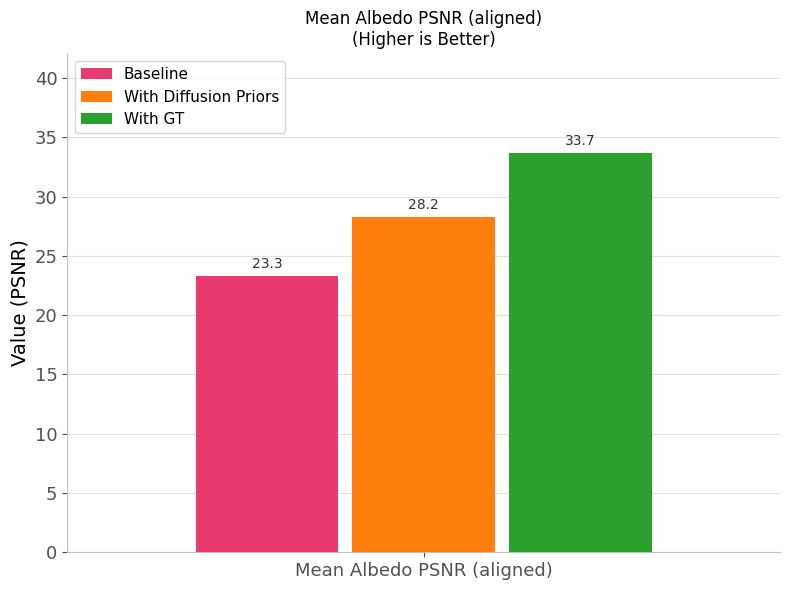

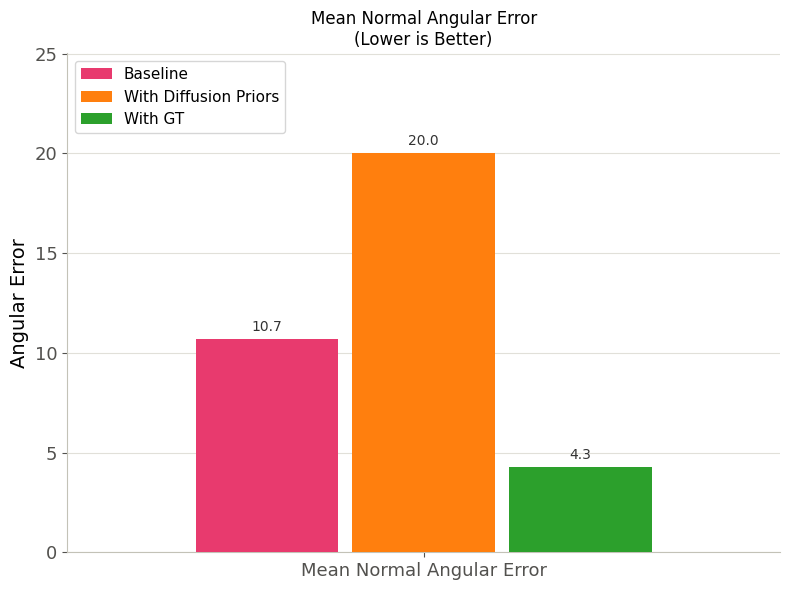

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.DataFrame(data)
df = df.reindex(sorted(df.columns), axis=1)

models = list(df.columns)
metrics = list(df.index)

# Adopt the requested colors
color_map = {
    'Baseline': '#E83A6E',
    'Baseline + direct': '#4472C4',
    'Baseline + zncc': '#70AD47',
    'Albedo + zncc': '#9B59B6',
}
cmap = plt.cm.get_cmap('tab10')
colors = [color_map.get(model, cmap(i % 10)) for i, model in enumerate(models)]

# Adopt the requested spacing
n_models = len(models)
bar_width = 0.2        
bar_step = 0.22         

def apply_styling(ax, y_max, metric_name):
    ax.set_xticks([0])
    ax.set_xticklabels([metric_name], fontsize=14)
    if 'PSNR' in metric_name:
        ax.set_ylabel('Value (PSNR)', fontsize=14)
        ax.set_title(f'{metric_name}\n(Higher is Better)')
    else:
        ax.set_ylabel('Angular Error', fontsize=14)
        ax.set_title(f'{metric_name}\n(Lower is Better)')
        
    ax.set_ylim(0, y_max)
    ax.set_xlim(-0.5, 0.5) # tighter xlim for a single group
    ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#c3c2b7')
    ax.spines['bottom'].set_color('#c3c2b7')
    ax.tick_params(colors='#52514e', labelsize=13)
    ax.legend(fontsize=11, frameon=True, loc='upper left')

# --- Plot 1: PSNR ---
metric1 = 'Mean Albedo PSNR (aligned)'
fig1, ax1 = plt.subplots(figsize=(8, 6))
y_max1 = df.loc[metric1].max() * 1.25

for i, model in enumerate(models):
    offset = (i - (n_models - 1) / 2) * bar_step
    val = df.loc[metric1, model]
    
    bars = ax1.bar([offset], [val], bar_width, color=colors[i], label=model, zorder=3)
    for bar in bars:
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            val + y_max1 * 0.01,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=10, color='#333333'
        )
        
apply_styling(ax1, y_max1, metric1)
plt.tight_layout()
# fig1.savefig('Mean_Albedo_PSNR_Styled.pdf', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Angular Error ---
metric2 = 'Mean Normal Angular Error'
fig2, ax2 = plt.subplots(figsize=(8, 6))
y_max2 = df.loc[metric2].max() * 1.25

for i, model in enumerate(models):
    offset = (i - (n_models - 1) / 2) * bar_step
    val = df.loc[metric2, model]
    
    bars = ax2.bar([offset], [val], bar_width, color=colors[i], label=model, zorder=3)
    for bar in bars:
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            val + y_max2 * 0.01,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=10, color='#333333'
        )
        
apply_styling(ax2, y_max2, metric2)
plt.tight_layout()
# fig2.savefig('Mean_Normal_Angular_Error_Styled.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame(data)

# Create a clean, professional-looking Excel file
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

wb = Workbook()
ws = wb.active
ws.title = "Results Summary"

# Write headers and data
for r in dataframe_to_rows(df, index=False, header=True):
    ws.append(r)

# Styling
header_font = Font(bold=True, color="FFFFFF")
header_fill = PatternFill(start_color="4F81BD", end_color="4F81BD", fill_type="solid")
center_alignment = Alignment(horizontal="center")
thin_border = Border(left=Side(style='thin'), right=Side(style='thin'), top=Side(style='thin'), bottom=Side(style='thin'))

# Format headers
for cell in ws[1]:
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = center_alignment
    cell.border = thin_border

# Format data
for row in ws.iter_rows(min_row=2, max_row=4, min_col=1, max_col=3):
    for cell in row:
        cell.alignment = center_alignment
        cell.border = thin_border

# Adjust column widths
ws.column_dimensions['A'].width = 25
ws.column_dimensions['B'].width = 20
ws.column_dimensions['C'].width = 25

# Save
wb.save('evaluation_metrics_table.xlsx')

ModuleNotFoundError: No module named 'openpyxl'